# Create Healthy Validation Date Dictionary

This notebook finds a clean 6-month BTC-USD and ETH-USD date range, validates its quality, and builds in-memory training, validation, and test windows.

No files are written. The final result is a dictionary of date ranges.

## 1. Load BTC and ETH Data

In [1]:
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

from binance_data_collector import BinanceDataCollector

symbols = ['BTC-USD', 'ETH-USD']
days_back = 365

collector = BinanceDataCollector()
raw_data = collector.fetch_crypto_data(symbols=symbols, interval='1m', days_back=days_back)
raw_data['Date'] = pd.to_datetime(raw_data['Date'])

print(f"Fetched {len(raw_data)} rows for {symbols} ({days_back} days)")
print(f"Date range: {raw_data['Date'].min().date()} to {raw_data['Date'].max().date()}")
print(f"Columns: {list(raw_data.columns)}")


INFO:root:Fetching Binance data for 2 symbols...
INFO:root:Interval: 1m, Days back: 365
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 1000 records for BTC-USD
INFO:root:Fetching 1m data for BTCUSDT...
INFO:root:Fetched 10

Fetched 1051200 rows for ['BTC-USD', 'ETH-USD'] (365 days)
Date range: 2025-07-06 to 2026-07-06
Columns: ['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume', 'Quote_volume', 'Count', 'Taker_buy_volume', 'Taker_buy_quote_volume']


## 2. Plot and check NAs

In [2]:
numeric_cols = raw_data.select_dtypes(include=['number']).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in ['Date']]

print('Numeric columns:')
print(numeric_cols)

print('Feature columns for preprocessing:')
print(feature_cols)

Numeric columns:
['Open', 'High', 'Low', 'Close', 'Volume', 'Quote_volume', 'Count', 'Taker_buy_volume', 'Taker_buy_quote_volume']
Feature columns for preprocessing:
['Open', 'High', 'Low', 'Close', 'Volume', 'Quote_volume', 'Count', 'Taker_buy_volume', 'Taker_buy_quote_volume']


In [3]:
from data_preprocessor import DataPreprocessor
preprocessor = DataPreprocessor()
processed_data = preprocessor.prepare_features(raw_data, target_col='Returns', drop_bad_values=False)
#processed_data.head()
#numeric_cols = processed_data.select_dtypes(include=['number']).columns.tolist()
processed_data.set_index(['Date', 'Symbol'], inplace = True)
preprocessor.scale_features(processed_data[numeric_cols], scaler = 'minmax')

INFO:root:Starting feature preparation...


Calculating volatility from OHLC data...


INFO:root:Added volatility features
INFO:root:Calculating technical indicators...
INFO:root:Added technical indicators
INFO:root:Using target: Returns
INFO:root:Creating lagged features...
INFO:root:Creating momentum features...
INFO:root:Creating OHLC ratios...
INFO:root:Cleaning data...
INFO:root: No rows removed, but NaN/inf values remain in the dataset
INFO:root:Feature preparation complete. Total features: 55
INFO:root:Dataset shape: (1051200, 53)
INFO:root:Features: 55
INFO:root:Target: Returns


,,Open,High,Low,Close,Volume,Quote_volume,Count,Taker_buy_volume,Taker_buy_quote_volume
Date,Symbol,,,,,,,,,
2025-07-06 22:20:00,BTC-USD,0.866656,0.866063,0.866711,0.866408,0.000194,0.004954,0.003047,0.000258,0.005498
2025-07-06 22:21:00,BTC-USD,0.866408,0.865922,0.866284,0.866018,0.000155,0.003970,0.005779,0.000122,0.002601
2025-07-06 22:22:00,BTC-USD,0.866018,0.865630,0.865908,0.865858,0.000225,0.005745,0.005810,0.000145,0.003099
2025-07-06 22:23:00,BTC-USD,0.865857,0.865350,0.866161,0.865943,0.000058,0.001509,0.002176,0.000034,0.000735
2025-07-06 22:24:00,BTC-USD,0.865943,0.865485,0.866044,0.865827,0.000096,0.002472,0.003271,0.000074,0.001593
...,...,...,...,...,...,...,...,...,...,...
2026-07-06 22:15:00,ETH-USD,0.002424,0.002411,0.002466,0.002418,0.003414,0.001429,0.002612,0.002154,0.000760
2026-07-06 22:16:00,ETH-USD,0.002417,0.002411,0.002464,0.002424,0.004509,0.001889,0.002848,0.006468,0.002283
2026-07-06 22:17:00,ETH-USD,0.002423,0.002412,0.002470,0.002425,0.001855,0.000774,0.001980,0.000833,0.000294


Returns
Date                Symbol          
2025-07-06 22:20:00 BTC-USD      NaN
                    ETH-USD      NaN

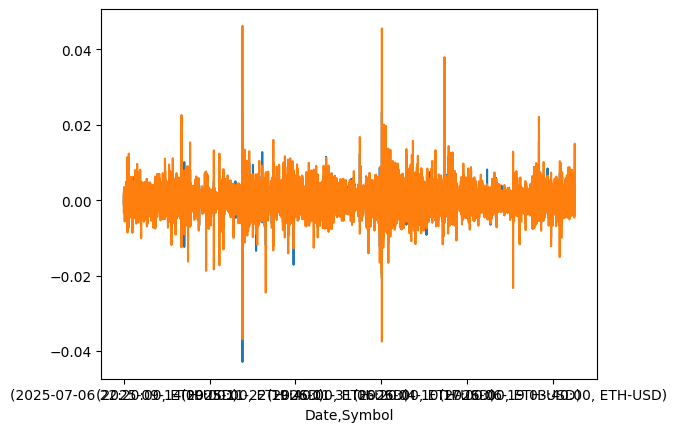

In [4]:
processed_data.groupby('Symbol')['Returns'].plot()
processed_data.loc[processed_data['Returns'].isna(),['Returns']]

In [5]:
btc_raw_data = raw_data[raw_data['Symbol'] == 'BTC-USD']
btc_raw_data.dropna(inplace = True)

In [6]:
btc_raw_data['Volume'].describe()


count    525600.000000
mean         13.184955
std          25.983450
min           0.067200
25%           3.090180
50%           6.521725
75%          13.834672
max        2001.279800
Name: Volume, dtype: float64

## 3. Produce the six month training window, then split the remainder into validation and test.

In [15]:
import json
import pathlib as pl
unique_dates = sorted(raw_data['Date'].dt.normalize().unique())
print(f"Unique dates: {len(unique_dates)}")

start_date = pd.Timestamp(unique_dates[0])
train_cutoff = start_date + pd.DateOffset(months=6)

train_dates = [date for date in unique_dates if pd.Timestamp(date) < train_cutoff]
remaining_dates = [date for date in unique_dates if pd.Timestamp(date) >= train_cutoff]

if len(train_dates) == 0:
    raise ValueError("Not enough data to build a 6-month training window.")

if len(remaining_dates) < 2:
    raise ValueError("Not enough remaining data for validation and test windows after the 6-month training period.")

val_cut = len(remaining_dates) // 2
validation_dates = remaining_dates[:val_cut]
test_dates = remaining_dates[val_cut:]

date_dictionary = {
    'symbols': symbols,
    'days_back': days_back,
    'total_unique_dates': len(unique_dates),
    'train': {
        'start': pd.Timestamp(train_dates[0]).date().isoformat(),
        'end': pd.Timestamp(train_dates[-1]).date().isoformat(),
        'count': len(train_dates),
    },
    'validation': {
        'start': pd.Timestamp(validation_dates[0]).date().isoformat(),
        'end': pd.Timestamp(validation_dates[-1]).date().isoformat(),
        'count': len(validation_dates),
    },
    'test': {
        'start': pd.Timestamp(test_dates[0]).date().isoformat(),
        'end': pd.Timestamp(test_dates[-1]).date().isoformat(),
        'count': len(test_dates),
    },
}

print("\nDate Dictionary:")
print(date_dictionary)


with open('healthy_dates.json', 'w') as f:
    json.dump(date_dictionary, f)


Unique dates: 366

Date Dictionary:
{'symbols': ['BTC-USD', 'ETH-USD'], 'days_back': 365, 'total_unique_dates': 366, 'train': {'start': '2025-07-06', 'end': '2026-01-05', 'count': 184}, 'validation': {'start': '2026-01-06', 'end': '2026-04-06', 'count': 91}, 'test': {'start': '2026-04-07', 'end': '2026-07-06', 'count': 91}}


In [8]:
date_dictionary

{'symbols': ['BTC-USD', 'ETH-USD'],
 'days_back': 365,
 'total_unique_dates': 366,
 'train': {'start': '2025-07-06', 'end': '2026-01-05', 'count': 184},
 'validation': {'start': '2026-01-06', 'end': '2026-04-06', 'count': 91},
 'test': {'start': '2026-04-07', 'end': '2026-07-06', 'count': 91}}